In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import ttest_ind # for hypothesis testing
import scipy.stats as stats
from sqlalchemy import create_engine
warnings.filterwarnings('ignore')

# Loading the Dataset

In [2]:
# Loading dataset
conn = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")

# Fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalExciseTax,FreightCost,COGS,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.270000,36.990002,1750.0,145080.0,3.811252e+06,142049.0,5.101920e+06,263044.0,68601.680141,3.731627e+06,1.370292e+06,26.86,0.979108,1.367210
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.190001,28.990000,1750.0,164038.0,3.804041e+06,160247.0,4.819073e+06,296242.0,144929.240166,3.716128e+06,1.102945e+06,22.89,0.976890,1.296800
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.240000,24.990000,1750.0,187407.0,3.418304e+06,187140.0,4.538121e+06,345530.0,123780.220203,3.413434e+06,1.124687e+06,24.78,0.998575,1.329488
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.170000,22.990000,1750.0,201682.0,3.261198e+06,200412.0,4.475973e+06,369710.0,257032.069523,3.240662e+06,1.235311e+06,27.60,0.993703,1.381191
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.889999,29.990000,1750.0,138109.0,3.023206e+06,135838.0,4.223108e+06,251624.0,257032.069523,2.973494e+06,1.249614e+06,29.59,0.983556,1.420251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.320000,4.990000,750.0,2.0,2.640000e+00,5.0,1.595000e+01,0.0,27100.410036,6.600000e+00,9.349999e+00,58.62,2.500000,2.416667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.390000,0.490000,50.0,6.0,2.340000e+00,134.0,6.566000e+01,6.0,50293.619843,5.226000e+01,1.340000e+01,20.41,22.333333,1.256410
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.740000,0.990000,50.0,2.0,1.480000e+00,2.0,1.980000e+00,0.0,14069.870026,1.480000e+00,5.000000e-01,25.25,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.470000,1.990000,200.0,1.0,1.470000e+00,72.0,1.432800e+02,4.0,257032.069523,1.058400e+02,3.744000e+01,26.13,72.000000,1.353741


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269376,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246018,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693354,123067.799573,0.710000,453.457510,3655.464971,20738.244730,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074317,167655.266047,0.000000,729.219982,5298.044970,28396.914894,5.101920e+06
TotalExciseTax,10692.0,1771.026281,11178.122436,0.000000,2.000000,16.000000,214.000000,3.697100e+05


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  object 
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  object 
 4   PurchasePrice          10692 non-null  float64
 5   ActualPrice            10692 non-null  float64
 6   Volume                 10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  float64
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10692 non-null  float64
 10  TotalSalesDollars      10692 non-null  float64
 11  TotalExciseTax         10692 non-null  float64
 12  FreightCost            10692 non-null  float64
 13  COGS                   10692 non-null  float64
 14  GrossProfit            10692 non-null  float64
 15  Pr

# Exploratory Data Analysis

- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be
included in the final analysis.

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns,
identify anomalies, and ensure data quality before proceeding with further analysis.

In [5]:
# summary stattistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269376,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246018,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693354,123067.799573,0.710000,453.457510,3655.464971,20738.244730,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074317,167655.266047,0.000000,729.219982,5298.044970,28396.914894,5.101920e+06
TotalExciseTax,10692.0,1771.026281,11178.122436,0.000000,2.000000,16.000000,214.000000,3.697100e+05


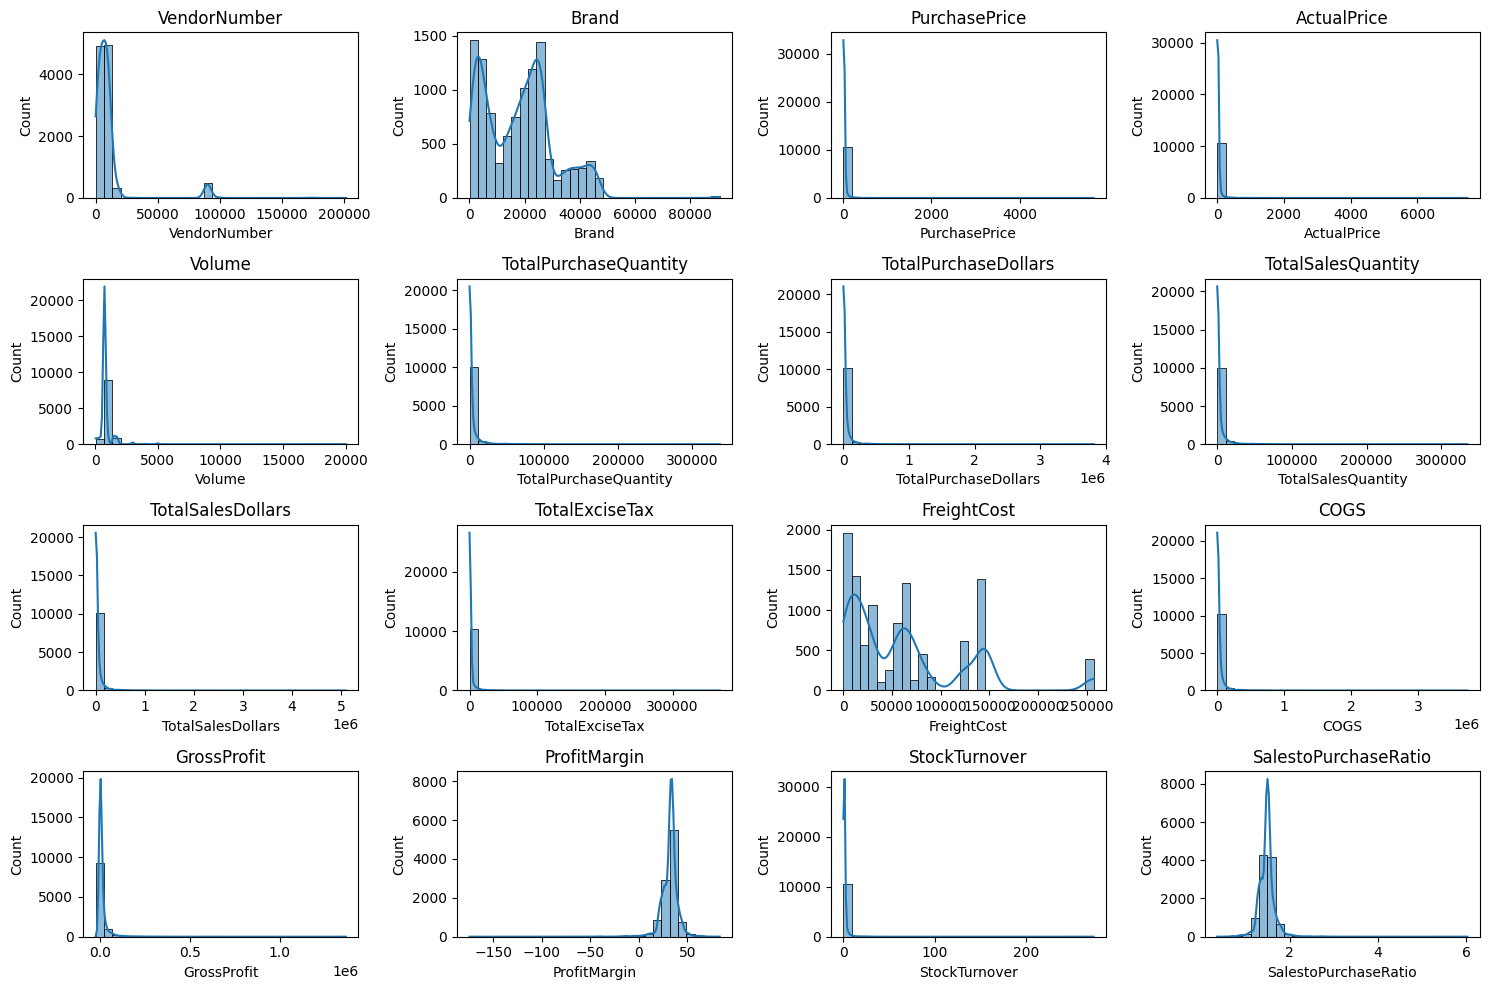

In [6]:
# Distribution plot for infinite columns
numerical_cols = df.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde = True,bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

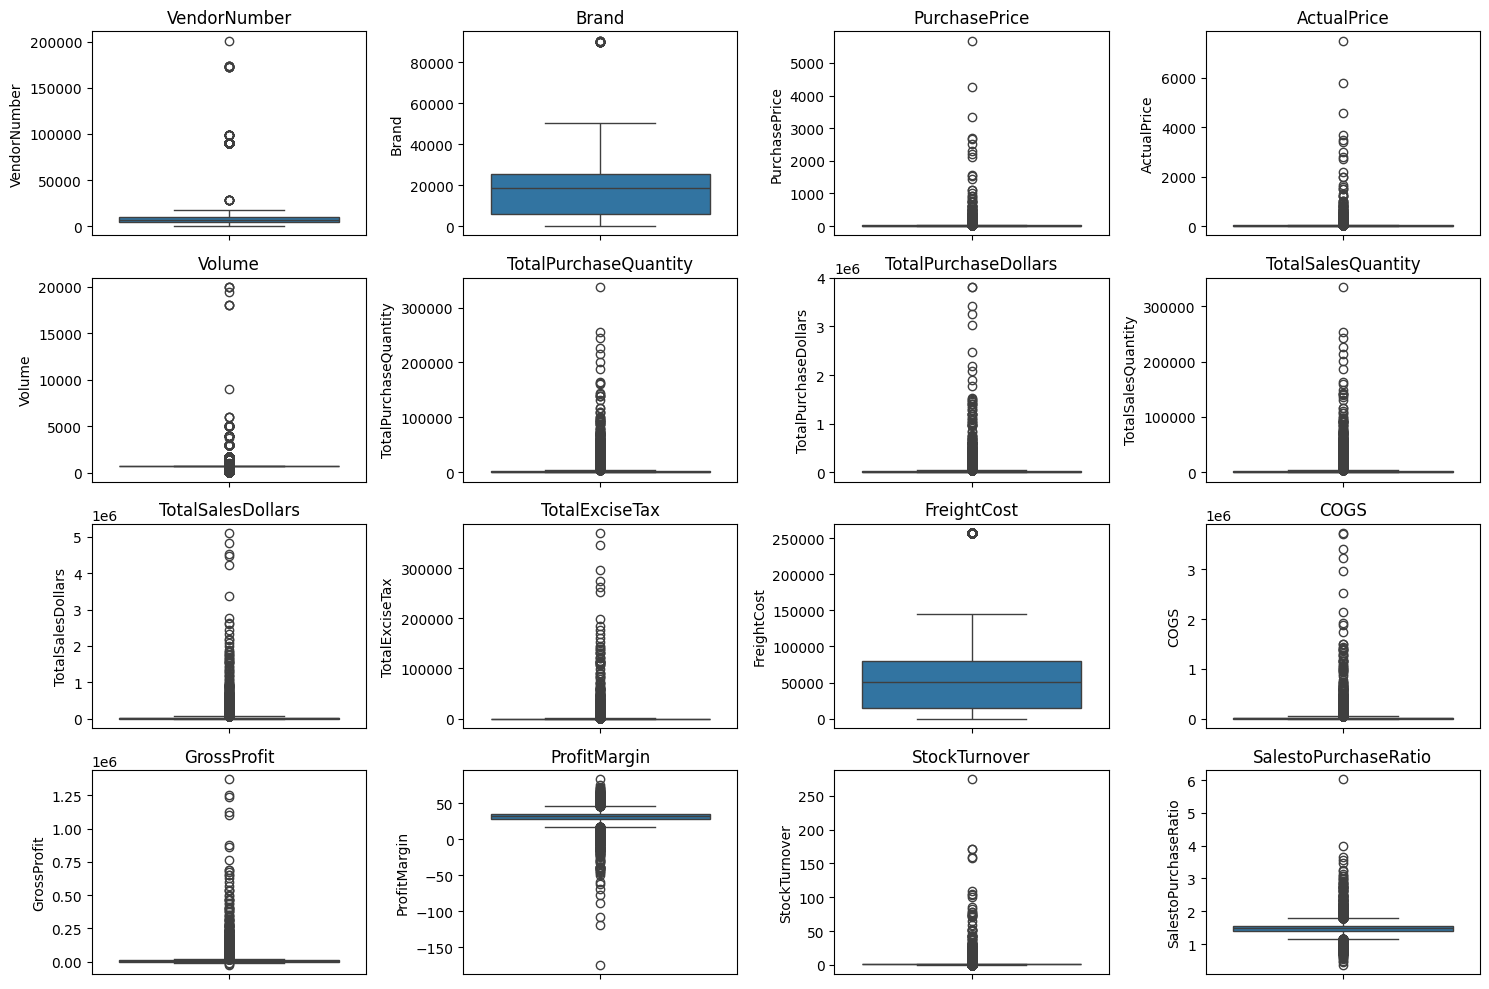

In [7]:
# Outerliers Detection with boxplots
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:
**Negative & Zero Values:**

- Gross Profit: Minimum value is -24,762.39, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts
lower than the purchase price ..
- Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolet
stock.

**Outliers Indicated by High Standard Deviations:**

- Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium
products.
- Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that
Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [8]:
# Let's filter the data by removing incosistencies
df = pd.read_sql_query("""select * 
from vendor_sales_summary
where GrossProfit>0
and ProfitMargin>0
and TotalSalesQuantity>0""",conn)

In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalExciseTax,FreightCost,COGS,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.270000,36.990002,1750.0,145080.0,3.811252e+06,142049.0,5.101920e+06,263044.0,68601.680141,3.731627e+06,1.370292e+06,26.86,0.979108,1.367210
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.190001,28.990000,1750.0,164038.0,3.804041e+06,160247.0,4.819073e+06,296242.0,144929.240166,3.716128e+06,1.102945e+06,22.89,0.976890,1.296800
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.240000,24.990000,1750.0,187407.0,3.418304e+06,187140.0,4.538121e+06,345530.0,123780.220203,3.413434e+06,1.124687e+06,24.78,0.998575,1.329488
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.170000,22.990000,1750.0,201682.0,3.261198e+06,200412.0,4.475973e+06,369710.0,257032.069523,3.240662e+06,1.235311e+06,27.60,0.993703,1.381191
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.889999,29.990000,1750.0,138109.0,3.023206e+06,135838.0,4.223108e+06,251624.0,257032.069523,2.973494e+06,1.249614e+06,29.59,0.983556,1.420251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10405,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.320000,4.990000,750.0,2.0,2.640000e+00,5.0,1.595000e+01,0.0,27100.410036,6.600000e+00,9.349999e+00,58.62,2.500000,2.416667
10406,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.390000,0.490000,50.0,6.0,2.340000e+00,134.0,6.566000e+01,6.0,50293.619843,5.226000e+01,1.340000e+01,20.41,22.333333,1.256410
10407,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.740000,0.990000,50.0,2.0,1.480000e+00,2.0,1.980000e+00,0.0,14069.870026,1.480000e+00,5.000000e-01,25.25,1.000000,1.337838
10408,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.470000,1.990000,200.0,1.0,1.470000e+00,72.0,1.432800e+02,4.0,257032.069523,1.058400e+02,3.744000e+01,26.13,72.000000,1.353741


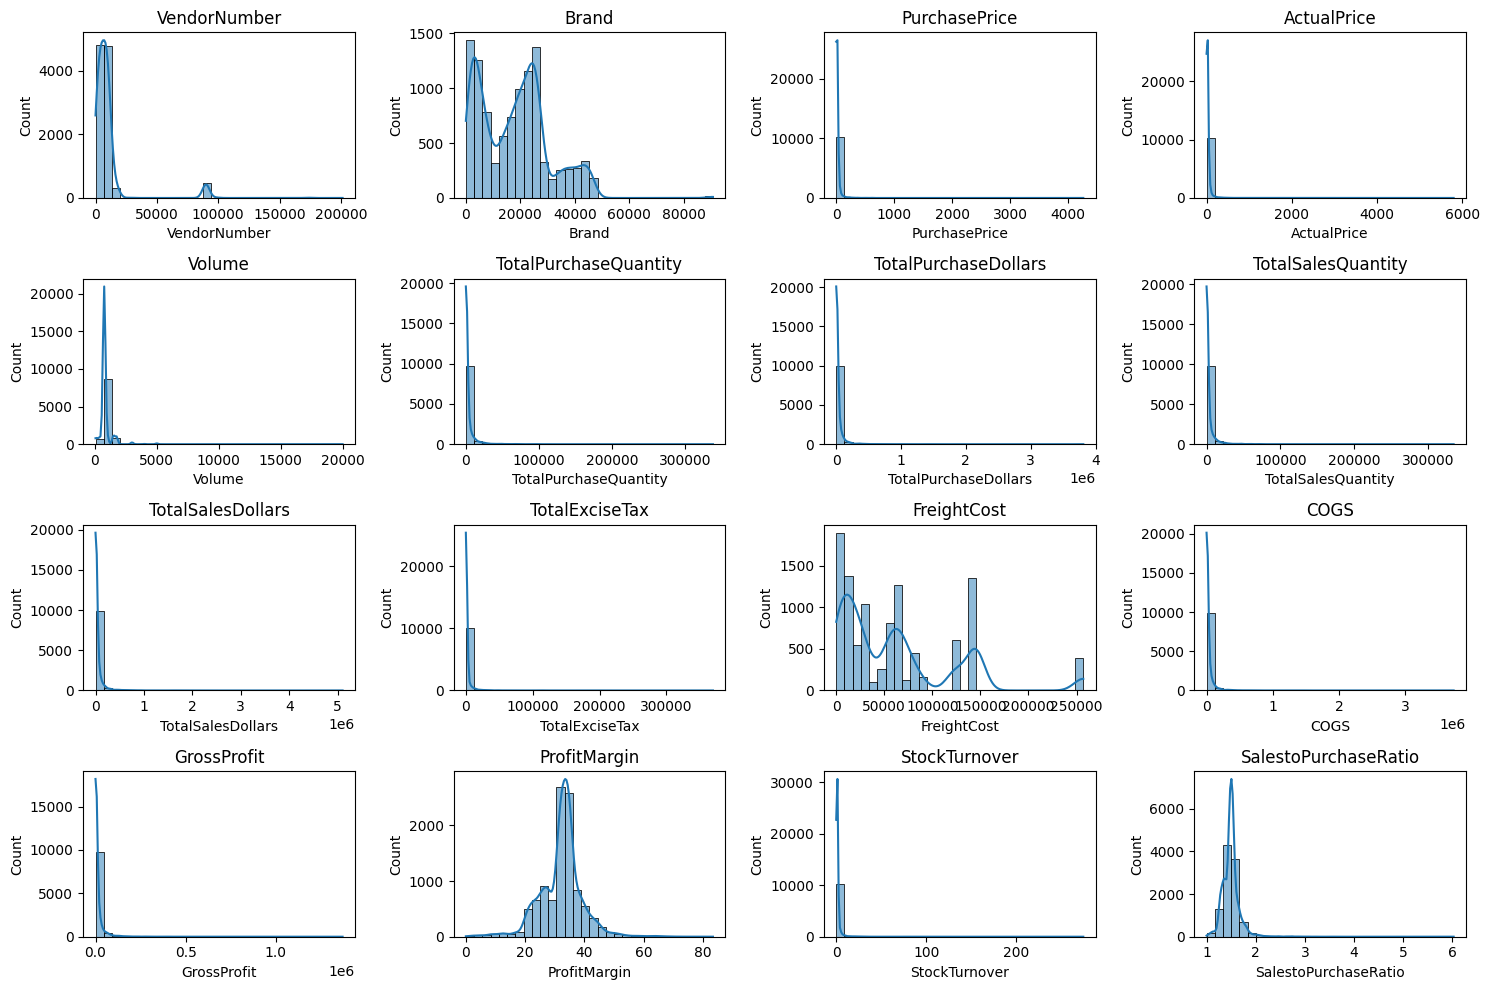

In [10]:
# Distribution plot for infinite columns
numerical_cols = df.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde = True,bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

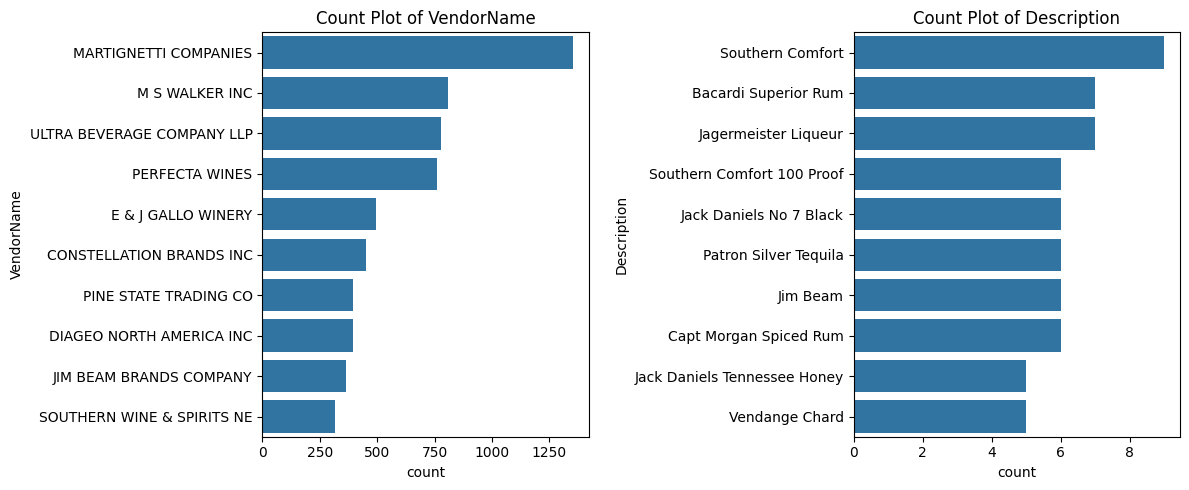

In [11]:
# Count plots for Categorical columns
categorical_cols =["VendorName","Description"]
plt.figure(figsize = (12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order =df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

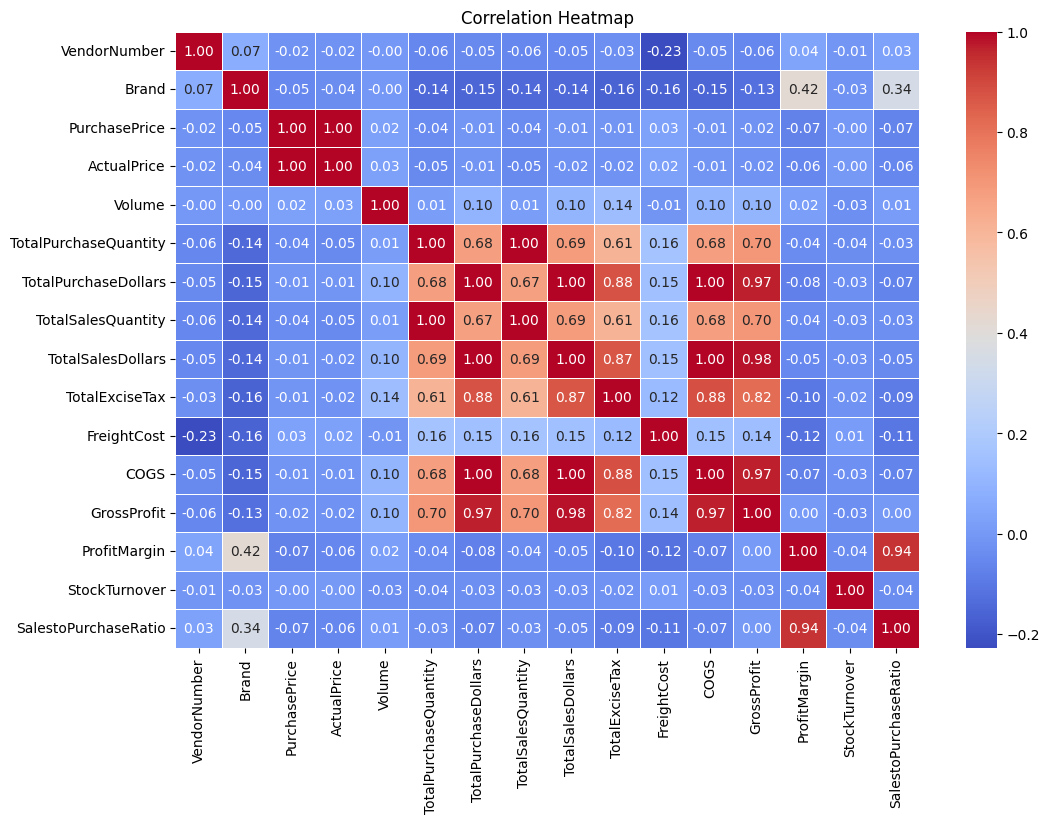

In [12]:
# Correlation Heatmap
plt.figure(figsize =(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths = 0.5)
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights

- PurchasePrice has weak correlations with TotalSalesDollars (-0.012), suggesting that price variations do not significantly impact
sales revenue.
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive
pricing pressures.
- StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.045), indicating that faster turnover does not necessarily
result in higher profitability.

# Data Analysis

#### **Identify Brands that needs Promotional or Pricing Adjustments which exibits lower sales performance but higher profit margins.**

In [13]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin': 'mean'}).reset_index()
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.090954,26.07
1,.nparalleled Svgn Blanc,1094.629976,32.92
2,10 Span Cab Svgn CC,2703.889938,33.78
3,10 Span Chard CC,3325.559910,31.51
4,10 Span Pnt Gris Monterey Cy,2082.219936,34.58
...,...,...,...
9385,Zuccardi Q Cab Svgn,1059.469990,32.42
9386,Zuccardi Q Malbec,1639.179983,35.07
9387,Zum Rsl,10857.339804,34.22
9388,Zwack Liqueur,227.880001,23.06


In [14]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
print(low_sales_threshold)

335.77050733566284


In [16]:
print(high_margin_threshold)

37.95


In [17]:
# Filters Brands with low sales but hight profit margin
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars']<=low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
    ]
print("Brands with low sales but high profit margins:")
display(target_brands.sort_values('TotalSalesDollars'))
    


Brands with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
1401,Camelot Chard,9.990000,45.55
7569,Santa Rita Organic Svgn Bl,9.990000,66.47
2352,Clos Amador Brut Cava,13.990000,44.67
2464,Concannon Glen Ellen Wh Zin,15.950000,58.62
4134,Hacienda Zargon Merlot,19.980000,44.84
...,...,...,...
8406,Tenuta Santo Pietro Imago 11,329.250002,43.36
5597,Maggio Cab Svgn,333.660000,38.55
361,Apimed Trnava Mead,335.700008,40.13
4171,Hardys Whiskers Blake Tawny,335.759995,44.32


In [18]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

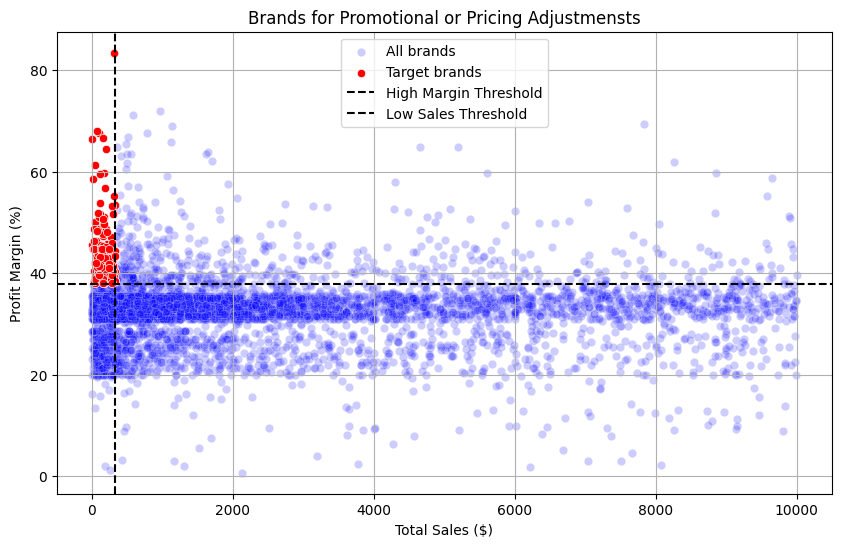

In [19]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = brand_performance, x='TotalSalesDollars',y='ProfitMargin',color = "blue",label = "All brands",alpha =0.2)
sns.scatterplot(data = target_brands, x = 'TotalSalesDollars',y='ProfitMargin',color='red',label='Target brands')

plt.axhline(high_margin_threshold, linestyle = '--',color ='black',label = 'High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle ='--',color ='black',label = "Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustmensts")
plt.legend()
plt.grid(True)
plt.show()

### **Which vendors and brands demonstrate the highest sales performance?**

In [20]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [21]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors.apply(lambda x:format_dollars(x))


VendorName
DIAGEO NORTH AMERICA INC      68.74M
MARTIGNETTI COMPANIES         40.62M
PERNOD RICARD USA             32.25M
JIM BEAM BRANDS COMPANY       31.86M
BACARDI USA INC               24.91M
CONSTELLATION BRANDS INC      24.47M
E & J GALLO WINERY            18.50M
BROWN-FORMAN CORP             18.48M
ULTRA BEVERAGE COMPANY LLP    17.45M
M S WALKER INC                15.33M
Name: TotalSalesDollars, dtype: object

In [22]:
top_brands.apply(lambda x: format_dollars(x))



Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

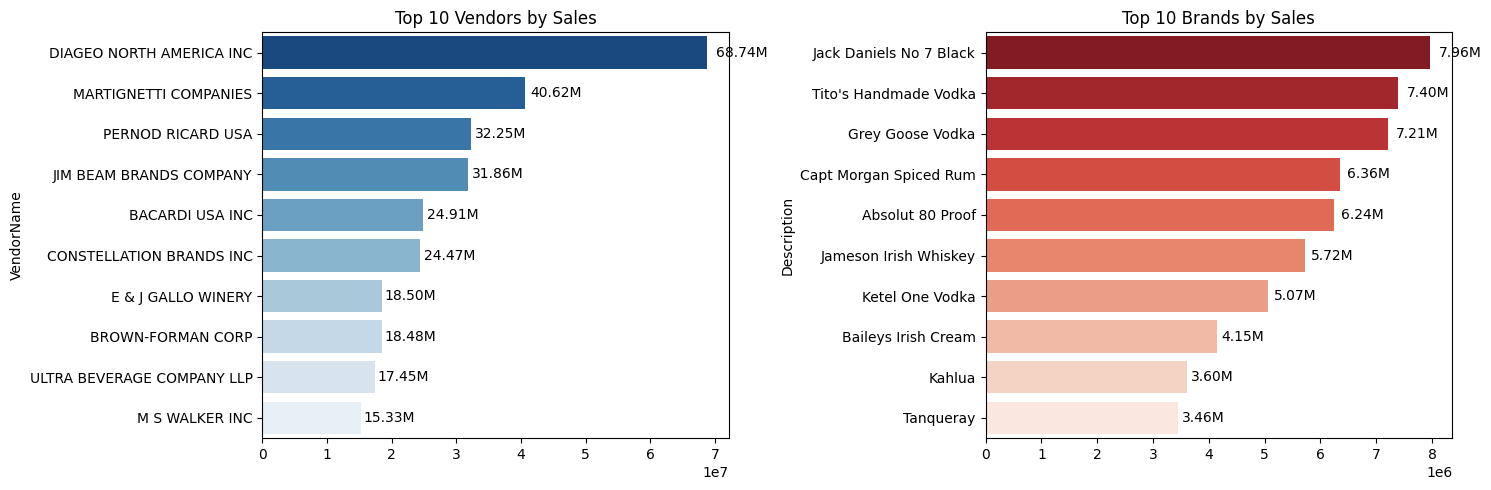

In [23]:
plt.figure(figsize = (15,5))

# Plot for Top vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y = top_vendors.index,x =top_vendors.values,palette = "Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width()*0.02),
             bar.get_y() +bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha = 'left' ,va ='center',fontsize=10,color='black')

#Plot for top brands
plt.subplot(1,2,2)
ax2 = sns.barplot(y = top_brands.index.astype(str),x =top_brands.values,palette = "Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width()*0.02),
             bar.get_y() +bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha = 'left' ,va ='center',fontsize=10,color='black')

plt.tight_layout()
plt.show()

## **Which vendor contributes the most to total purchase dollars?**

In [24]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()


In [25]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100

In [26]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,7.670365e+04,3.081168e+03,6.757622e+04,0.023998
1,ALISA CARR BEVERAGES,3.495168e+04,3.878066e+04,1.135902e+05,0.010935
2,ALTAMAR BRANDS LLC,1.170620e+04,4.464841e+03,1.570681e+04,0.003662
3,AMERICAN SPIRITS EXCHANGE,1.205160e+03,7.595801e+02,1.719970e+03,0.000377
4,AMERICAN VINTAGE BEVERAGE,1.563573e+05,4.584202e+04,1.901346e+05,0.048919
...,...,...,...,...,...
121,WEIN BAUER INC,4.351700e+04,1.546922e+04,5.693023e+04,0.013615
122,WESTERN SPIRITS BEVERAGE CO,3.290588e+05,1.069782e+05,4.249395e+05,0.102951
123,WILLIAM GRANT & SONS INC,5.960744e+06,2.110976e+06,7.635228e+06,1.864909
124,WINE GROUP INC,5.243587e+06,3.192763e+06,8.331160e+06,1.640535


In [27]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%',ascending = False),2)

In [28]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
27,DIAGEO NORTH AMERICA INC,50.96M,18.76M,68.74M,15.94
61,MARTIGNETTI COMPANIES,27.43M,14.07M,40.62M,8.58
49,JIM BEAM BRANDS COMPANY,24.10M,8.57M,31.86M,7.54
72,PERNOD RICARD USA,24.09M,8.72M,32.25M,7.54
7,BACARDI USA INC,17.51M,7.13M,24.91M,5.48
22,CONSTELLATION BRANDS INC,15.57M,9.13M,24.47M,4.87
13,BROWN-FORMAN CORP,13.53M,5.23M,18.48M,4.23
112,ULTRA BEVERAGE COMPANY LLP,12.75M,5.42M,17.45M,3.99
32,E & J GALLO WINERY,12.21M,6.58M,18.50M,3.82
57,M S WALKER INC,10.74M,4.99M,15.33M,3.36


In [29]:
top_vendors['Cummulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cummulative_Contribution%
27,DIAGEO NORTH AMERICA INC,50.96M,18.76M,68.74M,15.94,15.94
61,MARTIGNETTI COMPANIES,27.43M,14.07M,40.62M,8.58,24.52
49,JIM BEAM BRANDS COMPANY,24.10M,8.57M,31.86M,7.54,32.06
72,PERNOD RICARD USA,24.09M,8.72M,32.25M,7.54,39.60
7,BACARDI USA INC,17.51M,7.13M,24.91M,5.48,45.08
22,CONSTELLATION BRANDS INC,15.57M,9.13M,24.47M,4.87,49.95
13,BROWN-FORMAN CORP,13.53M,5.23M,18.48M,4.23,54.18
112,ULTRA BEVERAGE COMPANY LLP,12.75M,5.42M,17.45M,3.99,58.17
32,E & J GALLO WINERY,12.21M,6.58M,18.50M,3.82,61.99
57,M S WALKER INC,10.74M,4.99M,15.33M,3.36,65.35


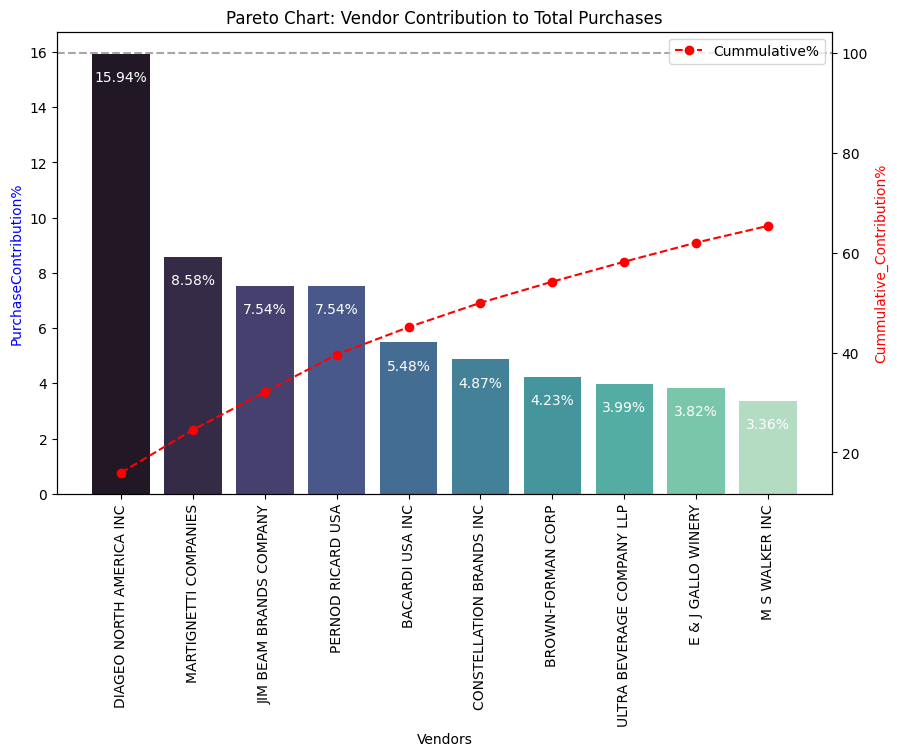

In [30]:
fig, ax1 =plt.subplots(figsize =(10,6))

#Bar plot or Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'],y = top_vendors['PurchaseContribution%'],palette ="mako",ax=ax1)

for i,value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value - 1,str(value) + '%',ha = 'center',fontsize =10,color ='white')

# Line plot for cummulative contribution
ax2 =ax1.twinx()
ax2.plot(top_vendors['VendorName'],top_vendors['Cummulative_Contribution%'],color='red',marker='o',linestyle='dashed',label='Cummulative%')

ax1.set_xticklabels(top_vendors['VendorName'],rotation =90)
ax1.set_ylabel('PurchaseContribution%', color='blue')
ax2.set_ylabel('Cummulative_Contribution%', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100,color='gray',linestyle ='dashed',alpha=0.7)
ax2.legend(loc='upper right')

plt.show()
    

## **How much of total procurement is dependent on the top vendors?**

In [31]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum() ,2) } %")

Total Purchase Contribution of top 10 vendors is 65.35 %


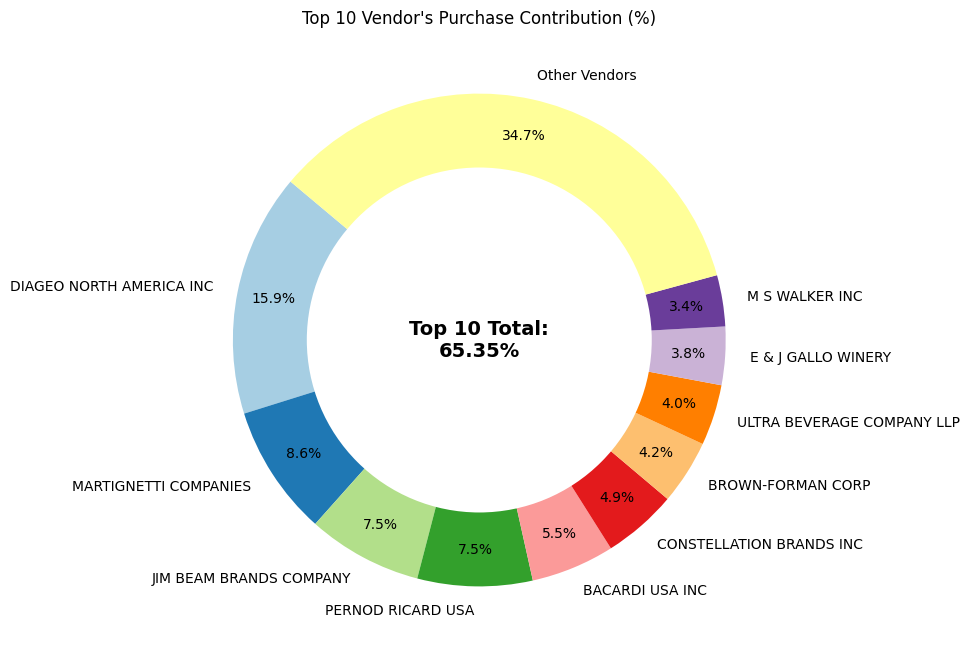

In [32]:
vendors = list(top_vendors ['VendorName' ].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution :.2f}%", fontsize=14, fontweight='bold', ha='center', va='center' )

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()



### **Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?**

In [33]:
df ['UnitPurchasePrice' ] = df ['TotalPurchaseDollars' ] / df ['TotalPurchaseQuantity' ]

In [34]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"],q=3, labels=["Small", "Medium", "Large"])

In [35]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,41.361991
Medium,17.857686
Large,11.242467


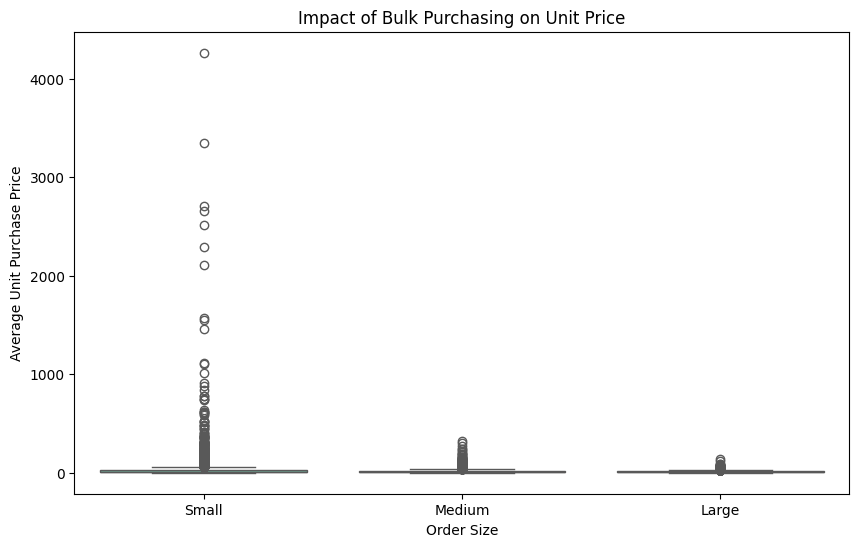

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()


- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit
revenue.

### **Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [52]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover').head(10).reset_index()

,VendorName,StockTurnover
0,TRUETT HURST,0.041667
1,"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
2,UNCORKED,0.217238
3,VINEYARD BRANDS LLC,0.256241
4,LOYAL DOG WINERY,0.308333
5,HIGHLAND WINE MERCHANTS LLC,0.335069
6,BLACK COVE BEVERAGES,0.340588
7,Russian Standard Vodka,0.394094
8,Serralles Usa LLC,0.414137
9,GILMANTON WINERY & VINEYARD,0.465819


### **How much capital locked in unsold inventory per vendor, and which vendors contribute the most to it?**

In [38]:
df["UnsoldInventoryValue"] = (df ["TotalPurchaseQuantity"] - df ["TotalSalesQuantity"]) * df ["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 8.35M


In [50]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName") ["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor ['UnsoldInventoryValue' ] = inventory_value_per_vendor['UnsoldInventoryValue']
inventory_value_per_vendor ['UnsoldInventoryValue%' ] = inventory_value_per_vendor['UnsoldInventoryValue']/inventory_value_per_vendor['UnsoldInventoryValue'].sum()*100
inventory_value_per_vendor ['UnsoldInventoryValuecumsum'] = inventory_value_per_vendor ['UnsoldInventoryValue%'].cumsum()
inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue,UnsoldInventoryValue%,UnsoldInventoryValuecumsum
27,DIAGEO NORTH AMERICA INC,980076.417117,11.741607,11.741607
61,MARTIGNETTI COMPANIES,872083.184707,10.447816,22.189423
49,JIM BEAM BRANDS COMPANY,810298.327360,9.707615,31.897038
112,ULTRA BEVERAGE COMPANY LLP,715981.676958,8.577674,40.474712
71,PERFECTA WINES,560314.245754,6.712731,47.187444
72,PERNOD RICARD USA,554740.667504,6.645958,53.833402
123,WILLIAM GRANT & SONS INC,436492.341495,5.229308,59.062710
57,M S WALKER INC,397538.278119,4.762627,63.825337
32,E & J GALLO WINERY,290499.412777,3.480269,67.305606
13,BROWN-FORMAN CORP,284906.606703,3.413266,70.718872


### **What is 95% confidence intervals for profit margins of top-performaing and low-performing vendors**

In [51]:
inventory_value_per_vendor ['UnsoldInventoryValue' ] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue,UnsoldInventoryValue%,UnsoldInventoryValuecumsum
27,DIAGEO NORTH AMERICA INC,980.08K,11.741607,11.741607
61,MARTIGNETTI COMPANIES,872.08K,10.447816,22.189423
49,JIM BEAM BRANDS COMPANY,810.30K,9.707615,31.897038
112,ULTRA BEVERAGE COMPANY LLP,715.98K,8.577674,40.474712
71,PERFECTA WINES,560.31K,6.712731,47.187444
72,PERNOD RICARD USA,554.74K,6.645958,53.833402
123,WILLIAM GRANT & SONS INC,436.49K,5.229308,59.062710
57,M S WALKER INC,397.54K,4.762627,63.825337
32,E & J GALLO WINERY,290.50K,3.480269,67.305606
13,BROWN-FORMAN CORP,284.91K,3.413266,70.718872


In [49]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df ["TotalSalesDollars"].quantile(0.25)

In [41]:
top_vendors = df [df ["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna()
low_vendors = df [df ["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna()

In [42]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) -1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (31.57, 32.15), Mean: 31.86
Low Vendors 95% CI: (32.77, 33.26), Mean: 33.01


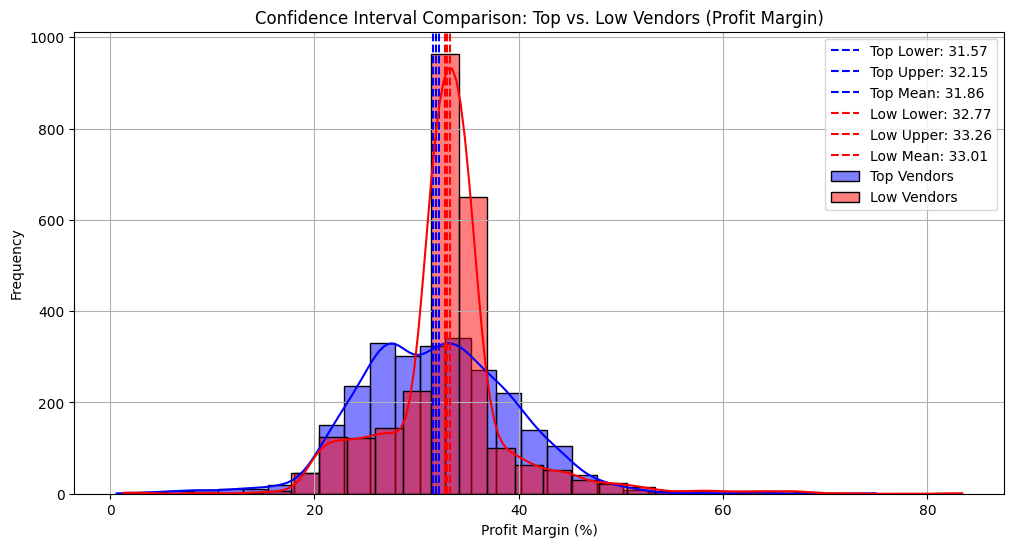

In [43]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower :.2f}, {top_upper :.2f}), Mean: {top_mean :.2f}")
print(f"Low Vendors 95% CI: ({low_lower :.2f}, {low_upper :.2f}), Mean: {low_mean :.2f}")

plt.figure(figsize=(12,6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower :.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper :.2f}")
plt.axvline(top_mean, color="blue", linestyle="--", label=f"Top Mean: {top_mean :.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower :.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper :.2f}")
plt.axvline(low_mean, color="red", linestyle="--", label=f"Low Mean: {low_mean :.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or imeroved
distribution strategies.

### **Is there a significant difference in profit margins between top-performing and low-performing vendors?**

Hypothesis:

He (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H, (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [44]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df [df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df [df ["TotalSalesDollars"] <= low_threshold]["ProfitMargin"]. dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat :.4f}, P-Value: {p_value :.4f}")
if p_value < 0.05:
  print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")
else:
  print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -5.9974, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.
